In [1]:
%pip install xlrd
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [17]:
from sentence_transformers import SentenceTransformer
import pandas as pd
from models.models import BertweetClassifier
from preprocessing_steps.data_cleanup import *
from sklearn.model_selection import train_test_split
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
import torch
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassConfusionMatrix

/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:

class BertweetClassifier(pl.LightningModule):
    def __init__(
        self,
        model_name: str = "vinai/bertweet-base",
        num_labels: int = 3,
        learning_rate: float = 5e-5,
        warmup_ratio: float = 0.10,
        freeze_encoder: bool = True,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate
        self.warmup_ratio = warmup_ratio

        # 1) encoder
        self.encoder = SentenceTransformer(model_name)

        # 2) simple linear head
        hidden = self.encoder.get_sentence_embedding_dimension()
        # self.classifier = nn.Linear(hidden, num_labels)
        hidden_dim = 64
        self.classifier = nn.Sequential(
            nn.Linear(hidden, num_labels),
            # nn.Linear(hidden, hidden_dim),
            # nn.ReLU(),
            # nn.Dropout(0.3),
            # nn.Linear(hidden_dim, num_labels)
        )

        # 3) (optionally) freeze encoder
        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.loss_fn = nn.CrossEntropyLoss()

    # Forward expects ONLY the list[str] texts
    def forward(self, texts: list[str]):
        embeds = self.encoder.encode(texts, convert_to_tensor=True, device=self.device)
        return self.classifier(embeds)

    # ------------------------------------------------------------------
    # Shared step to avoid duplication
    def _shared_step(self, batch, stage: str):
        texts, labels = batch                    # <- from our collate_fn
        logits = self(texts)
        loss   = self.loss_fn(logits, labels.to(self.device))

        preds  = logits.argmax(1)
        acc    = (preds == labels.to(self.device)).float().mean()

        # nice logging
        self.log(f"{stage}_loss", loss,  prog_bar=True, on_step=(stage=="train"), on_epoch=True)
        self.log(f"{stage}_acc",  acc,   prog_bar=True, on_epoch=True,   on_step=False)
        # print(f"{stage}_loss", loss,  prog_bar=True, on_step=(stage=="train"), on_epoch=True)
        # print(f"{stage}_acc",  acc,   prog_bar=True, on_epoch=True,   on_step=False)
        return loss


    # Lightning API -----------------------------------------------------
    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        # Re-use the same bookkeeping you used for val:
        self._shared_step(batch, stage="test")
        
    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        # `batch` is just a list[str] from your predict_dataloader
        texts = batch
        logits = self(texts)
        probs  = torch.softmax(logits, dim=-1)
        return probs  

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=0.01)
        total_steps  = self.trainer.estimated_stepping_batches
        warmup_steps = int(self.hparams.warmup_ratio * total_steps)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        return {
            "optimizer":  optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",      # step every batch
                "frequency": 1,
                "name": "linear-warmup",
            },
        }
    
def get_dataloader_labeled(df=None, text_column='clean_tweet', target=None, shuffle=True, batch_size=64, drop_last=True):
  data = list(zip(df[text_column].tolist(), df[target].tolist()))
  dataloader = DataLoader(df, shuffle=shuffle, batch_size=batch_size,
                          collate_fn=lambda x:x, drop_last=drop_last)
  return dataloader


class TweetsDataModule(pl.LightningDataModule):
    def __init__(self, data: pd.DataFrame, batch_size: int = None, target_col: str = 'AR'):
        super().__init__()
        self.data = data.copy()
        self.batch_size = batch_size
        self.target_col = target_col

        self.label2id: dict[str, int] = {}
        self.id2label: list[str]      = []
    
    def setup(self, stage: str=None):
        # Assign train/val datasets for use in dataloaders
        self.data = preprocess_text(self.data, text_col="text")
        # self.data = self.data[['clean_text', self.target_col]]

        uniques          = sorted(self.data[self.target_col].unique())
        self.label2id    = {lbl: i for i, lbl in enumerate(uniques)}
        self.id2label    = uniques                            # same order
        self.data["y"]   = self.data[self.target_col].map(self.label2id)    

        train, test = train_test_split(self.data, train_size=0.8, random_state=2025, shuffle=True)
        self.train, self.val = train_test_split(train, train_size=0.8, random_state=2025, shuffle=True)
        # self.train = train
        # self.val = test
        self.test = self.val


    def train_dataloader(self):
        #  NO super().__init__() here
        data = list(zip(self.train["clean_text"], self.train["y"]))
        return DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=True,
            collate_fn=lambda batch: ( [t for t, _ in batch],
                                        torch.tensor([l for _, l in batch]) ),
            drop_last=True,
        )

    def val_dataloader(self):
        data = list(zip(self.val["clean_text"], self.val["y"]))
        return DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=lambda batch: ( [t for t, _ in batch],
                                        torch.tensor([l for _, l in batch]) ),
        )

    def test_dataloader(self):
        data = list(zip(self.test["clean_text"], self.test["y"]))
        return DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=lambda batch: ( [t for t, _ in batch],
                                        torch.tensor([l for _, l in batch]) ),
        )
    
    def predict_dataloader(self):
        """
        Returns a DataLoader for inference.
        - If you called `setup("predict")`, it will use `self.test`.
        - If you created `self.predict` manually (e.g., a new DataFrame without labels),
          that takes precedence.
        Collate fn yields a *list[str]* so the model’s forward just receives raw texts.
        """
        dataset = getattr(self, "predict", None)
        if dataset is None:          # fall back to the held-out test set
            dataset = self.test

        texts = list(dataset["clean_text"])

        return DataLoader(
            texts,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=lambda batch: batch  # returns List[str] per batch
        )


tweets_labeled = pd.read_csv('data/training_data_labelled.csv')
tweets_labeled['AR'].replace({4:2}, inplace=True)
dataModule = TweetsDataModule(tweets_labeled, 32, target_col="AR")
dataModule.setup()
model_name = "digio/Twitter4SSE"
model_name2 = "peulsilva/sentence-transformer-trained-tweet"
model = BertweetClassifier(
    model_name=model_name2,
    learning_rate=5e-5,
    freeze_encoder=True,
    num_labels=len(dataModule.id2label)           # keep model & data in sync
)
model.id2label = dataModule.id2label          # list   -> e.g. ["neg","neu","pos"]
model.label2id = dataModule.label2id
logger = TensorBoardLogger("tb_logs")
trainer = pl.Trainer(max_epochs=5, logger = logger)
trainer.fit(model=model, datamodule=dataModule)


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Loading `train_dataloader` to estimate number of stepping batches.
/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

  | Name       | Type                | Params | Mode 
-----------------------------------------------------------
0 | encoder    | SentenceTransformer | 109 M  | train
1 | classifier | Sequential          | 2.3 K  | train
2 | loss_fn    | CrossEntropyLoss    | 0      | train
-------------------------------------------------

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 4: 100%|██████████| 74/74 [01:14<00:00,  0.99it/s, v_num=2, train_loss_step=0.813, val_loss=0.893, val_acc=0.649, train_loss_epoch=0.900, train_acc=0.628]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 74/74 [01:16<00:00,  0.97it/s, v_num=2, train_loss_step=0.813, val_loss=0.893, val_acc=0.649, train_loss_epoch=0.900, train_acc=0.628]


In [23]:
# 3epoch 5e-5lr: 
# 5epoch 5e-5lr: [{'test_loss': 0.8930990099906921, 'test_acc': 0.6492411494255066}]
# 5epoch 1e-4lr: [{'test_loss': 0.8230690956115723, 'test_acc': 0.6930860280990601}]

test_metrics = trainer.test(model=model, datamodule=dataModule)      # <- returns a list of dicts
print(test_metrics)

/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 19/19 [00:11<00:00,  1.63it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6492411494255066     │
│         test_loss         │    0.8930990099906921     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.8930990099906921, 'test_acc': 0.6492411494255066}]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/misha/Github/label_tweets/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 19/19 [00:00<00:00, 52.51it/s]


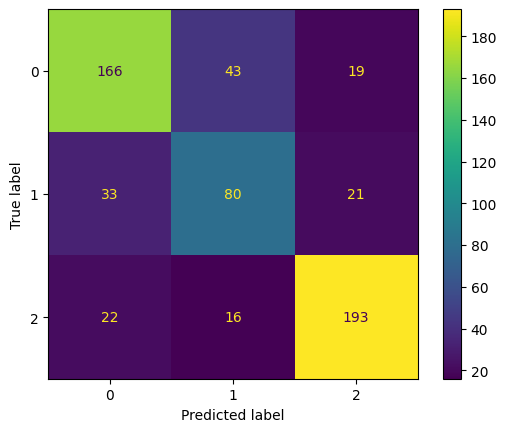

              precision    recall  f1-score   support

           0       0.75      0.73      0.74       228
           1       0.58      0.60      0.59       134
           2       0.83      0.84      0.83       231

    accuracy                           0.74       593
   macro avg       0.72      0.72      0.72       593
weighted avg       0.74      0.74      0.74       593



In [6]:
from sklearn.metrics import confusion_matrix,  classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import numpy as np

# ------------------------------------------------------------
# 1. Run inference -> stacked probability tensor
# ------------------------------------------------------------
preds = trainer.predict(model=model, datamodule=dataModule)

flat  = [tb for dev in preds for tb in (dev if isinstance(dev, list) else [dev])]
probs = torch.cat(flat).cpu().numpy()            # shape [N_samples, num_labels]

# ------------------------------------------------------------
# 2. Turn probs into predicted class IDs & labels
# ------------------------------------------------------------
pred_idx    = probs.argmax(axis=1)               # int IDs 0 … C-1
pred_labels = [dataModule.id2label[i] for i in pred_idx]

# ------------------------------------------------------------
# 3. Assemble a tidy DataFrame
# ------------------------------------------------------------
df_pred = dataModule.test.reset_index(drop=True).copy()
df_pred[[f"p_{lbl}" for lbl in dataModule.id2label]] = probs
df_pred["pred_idx"] = pred_idx
df_pred["pred"]     = pred_labels     # <- string label—for reports, plots, etc.

# ------------------------------------------------------------
# 4. Confusion matrix (true vs. predicted IDs)
# ------------------------------------------------------------
cm = confusion_matrix(
    df_pred["y"],            # true integer IDs stored earlier
    df_pred["pred_idx"],
    labels=np.arange(len(dataModule.id2label))
)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=np.arange(len(dataModule.id2label)))
disp.plot()
plt.show()


print(classification_report(df_pred["y"],df_pred["pred_idx"]))


In [7]:
df_pred.head()

incorrect = df_pred[df_pred["pred"] != df_pred["AR"]][["pred", "AR", "clean_text"]]
incorrect.to_csv("incorrect.csv")

In [8]:
def get_labels(df, col_name):
    conditions = [
        df[col_name] == 0,
        df[col_name] == 1,
        df[col_name] == 2
    ]
    choices = ['Problem', 'Solution', 'Other']
    return np.select(conditions, choices, default=np.NAN)

# Multi-label

In [ ]:

class BertweetClassifier(pl.LightningModule):
    def __init__(
        self,
        model_name: str = "vinai/bertweet-base",
        num_labels: int = 3,
        learning_rate: float = 5e-5,
        warmup_ratio: float = 0.10,
        freeze_encoder: bool = True,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate
        self.warmup_ratio = warmup_ratio

        # 1) encoder
        self.encoder = SentenceTransformer(model_name)

        # 2) simple linear head
        hidden = self.encoder.get_sentence_embedding_dimension()
        # self.classifier = nn.Linear(hidden, num_labels)
        hidden_dim = 64
        self.classifier = nn.Sequential(
            nn.Linear(hidden, num_labels),
            # nn.Linear(hidden, hidden_dim),
            # nn.ReLU(),
            # nn.Dropout(0.3),
            # nn.Linear(hidden_dim, num_labels)
        )

        # 3) (optionally) freeze encoder
        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.loss_fn = nn.BCEWithLogitsLoss()

    # Forward expects ONLY the list[str] texts
    def forward(self, texts: list[str]):
        embeds = self.encoder.encode(texts, convert_to_tensor=True, device=self.device)
        return self.classifier(embeds)

    # ------------------------------------------------------------------
    # Shared step to avoid duplication
    def _shared_step(self, batch, stage: str):
        texts, soft_labels, true_AR, true_MB = batch
        logits = self(texts)
        loss = self.loss_fn(logits, soft_labels.to(self.device))

        # Get probabilities
        preds = logits.argmax(1)

        acc_AR = (preds == true_AR.to(self.device)).float().mean()
        acc_MB = (preds == true_MB.to(self.device)).float().mean()

        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=(stage=="train"), on_epoch=True)
        self.log(f"{stage}_acc_AR", acc_AR, prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{stage}_acc_MB", acc_MB, prog_bar=True, on_epoch=True, on_step=False)

        # Optionally: return predictions for logging or downstream use
        # Return as a dict for Lightning
        return {
            "loss": loss,
            "preds": preds,
            "true_AR": true_AR,
            "true_MB": true_MB,
        }


    # Lightning API -----------------------------------------------------
    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        # Re-use the same bookkeeping you used for val:
        self._shared_step(batch, stage="test")
        
    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        # `batch` is just a list[str] from your predict_dataloader
        texts = batch
        logits = self(texts)
        probs  = torch.softmax(logits, dim=-1)
        return probs  

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=0.01)
        total_steps  = self.trainer.estimated_stepping_batches
        warmup_steps = int(self.hparams.warmup_ratio * total_steps)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        return {
            "optimizer":  optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",      # step every batch
                "frequency": 1,
                "name": "linear-warmup",
            },
        }
    
def get_dataloader_labeled(df=None, text_column='clean_tweet', target=None, shuffle=True, batch_size=64, drop_last=True):
  data = list(zip(df[text_column].tolist(), df[target].tolist()))
  dataloader = DataLoader(df, shuffle=shuffle, batch_size=batch_size,
                          collate_fn=lambda x:x, drop_last=drop_last)
  return dataloader


class TweetsDataModule(pl.LightningDataModule):
    def __init__(self, data: pd.DataFrame, batch_size: int = None, target_col: str = 'AR'):
        super().__init__()
        self.data = data.copy()
        self.batch_size = batch_size
        self.target_col = target_col

        self.label2id: dict[str, int] = {}
        self.id2label: list[str]      = []
    
    def setup(self, stage: str=None):
        # Assign train/val datasets for use in dataloaders
        self.data = preprocess_text(self.data, text_col="text")
        # self.data = self.data[['clean_text', self.target_col]]

        uniques          = sorted(self.data[self.target_col].unique())
        self.label2id    = {lbl: i for i, lbl in enumerate(uniques)}
        self.id2label    = uniques                            # same order
        self.data["y"]   = self.data[self.target_col].map(self.label2id)    
        self.data['AR_id'] = self.data['AR'].map(self.label2id)
        self.data['MB_id'] = self.data['MB'].map(self.label2id)

        train, test = train_test_split(self.data, train_size=0.8, random_state=2025, shuffle=True)
        self.train, self.val = train_test_split(train, train_size=0.8, random_state=2025, shuffle=True)
        # self.train = train
        # self.val = test
        self.test = self.val


    def train_dataloader(self):
        #  NO super().__init__() here
        data = list(zip(
            self.train["clean_text"], 
            self.train["soft_label"],
            self.train["AR_id"], 
            self.train["MB_id"]
        ))
        return DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=True,
            collate_fn=lambda batch: (
                [t for t, _, _, _ in batch],
                torch.tensor([l for _, l, _, _ in batch], dtype=torch.float32),
                torch.tensor([ar for _, _, ar, _ in batch], dtype=torch.long),
                torch.tensor([mb for _, _, _, mb in batch], dtype=torch.long),
            ),
            drop_last=True,
        )


    def val_dataloader(self):
        data = list(zip(
            self.val["clean_text"], 
            self.val["soft_label"],
            self.val["AR_id"], 
            self.val["MB_id"]
        ))
        return DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=True,
            collate_fn=lambda batch: (
                [t for t, _, _, _ in batch],
                torch.tensor([l for _, l, _, _ in batch], dtype=torch.float32),
                torch.tensor([ar for _, _, ar, _ in batch], dtype=torch.long),
                torch.tensor([mb for _, _, _, mb in batch], dtype=torch.long),
            )
        )

    def test_dataloader(self):
        data = list(zip(
            self.test["clean_text"], 
            self.test["soft_label"],
            self.test["AR_id"], 
            self.test["MB_id"]
        ))
        return DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=True,
            collate_fn=lambda batch: (
                [t for t, _, _, _ in batch],
                torch.tensor([l for _, l, _, _ in batch], dtype=torch.float32),
                torch.tensor([ar for _, _, ar, _ in batch], dtype=torch.long),
                torch.tensor([mb for _, _, _, mb in batch], dtype=torch.long),
            )
        )
    
    def predict_dataloader(self):
        """
        Returns a DataLoader for inference.
        - If you called `setup("predict")`, it will use `self.test`.
        - If you created `self.predict` manually (e.g., a new DataFrame without labels),
          that takes precedence.
        Collate fn yields a *list[str]* so the model’s forward just receives raw texts.
        """
        dataset = getattr(self, "predict", None)
        if dataset is None:          # fall back to the held-out test set
            dataset = self.test

        texts = list(dataset["clean_text"])

        return DataLoader(
            texts,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=lambda batch: batch  # returns List[str] per batch
        )


# tweets_labeled = pd.read_csv('data/training_data_labelled.csv')
# tweets_labeled['AR'].replace({4:2}, inplace=True)

# # Get all possible labels (ensure both columns)
# all_labels = sorted(set(tweets_labeled['AR']).union(set(tweets_labeled['MB'])))
# label2id = {lbl: idx for idx, lbl in enumerate(all_labels)}
# num_labels = len(all_labels)

# def make_soft_label(row):
#     arr = np.zeros(num_labels)
#     arr[label2id[row['AR']]] += 1
#     arr[label2id[row['MB']]] += 1
#     arr /= arr.sum()  # divide by 2
#     return arr

# tweets_labeled['soft_label'] = tweets_labeled.apply(make_soft_label, axis=1)

dataModule = TweetsDataModule(tweets_labeled, 32, target_col="AR")
dataModule.setup()
model_name = "digio/Twitter4SSE"
model_name2 = "peulsilva/sentence-transformer-trained-tweet"
model = BertweetClassifier(
    model_name=model_name2,
    learning_rate=1e-4,
    freeze_encoder=True,
    num_labels=len(dataModule.id2label)           # keep model & data in sync
)
model.id2label = dataModule.id2label          # list   -> e.g. ["neg","neu","pos"]
model.label2id = dataModule.label2id
logger = TensorBoardLogger("tb_logs")
trainer = pl.Trainer(max_epochs=8, logger = logger)
trainer.fit(model=model, datamodule=dataModule)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Loading `train_dataloader` to estimate number of stepping batches.
/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

  | Name       | Type                | Params | Mode 
-----------------------------------------------------------
0 | encoder    | SentenceTransformer | 109 M  | train
1 | classifier | Sequential          | 2.3 K  | train
2 | loss_fn    | BCEWithLogitsLoss   | 0      | train
-------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:476: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 0:  45%|████▍     | 33/74 [00:18<00:23,  1.74it/s, v_num=13, train_loss_step=0.670]

In [1]:
tweets_labeled.shape

NameError: name 'tweets_labeled' is not defined

In [ ]:
# 5epoch 5e-5lr:[{'test_loss': 0.5815809369087219, 'test_acc_AR': 0.5935919284820557, 'test_acc_MB': 0.5969645977020264}]
# 5epoch 1e-4lr: [{'test_loss': 0.5303563475608826, 'test_acc_AR': 0.6627318859100342, 'test_acc_MB': 0.6711635589599609}]

test_metrics = trainer.test(model=model, datamodule=dataModule)      # <- returns a list of dicts
print(test_metrics)

/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:476: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 19/19 [00:17<00:00,  1.12it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        test_acc_AR        │    0.6627318859100342     │
│        test_acc_MB        │    0.6711635589599609     │
│         test_loss         │    0.5303563475608826     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.5303563475608826, 'test_acc_AR': 0.6627318859100342, 'test_acc_MB': 0.6711635589599609}]


In [ ]:
from sklearn.metrics import confusion_matrix,  classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import numpy as np

# ------------------------------------------------------------
# 1. Run inference -> stacked probability tensor
# ------------------------------------------------------------
preds = trainer.predict(model=model, datamodule=dataModule)

flat  = [tb for dev in preds for tb in (dev if isinstance(dev, list) else [dev])]
probs = torch.cat(flat).cpu().numpy()            # shape [N_samples, num_labels]

# ------------------------------------------------------------
# 2. Turn probs into predicted class IDs & labels
# ------------------------------------------------------------
pred_idx    = probs.argmax(axis=1)               # int IDs 0 … C-1
pred_labels = [dataModule.id2label[i] for i in pred_idx]

# ------------------------------------------------------------
# 3. Assemble a tidy DataFrame
# ------------------------------------------------------------
df_pred = dataModule.test.reset_index(drop=True).copy()
df_pred[[f"p_{lbl}" for lbl in dataModule.id2label]] = probs
df_pred["pred_idx"] = pred_idx
df_pred["pred"]     = pred_labels     # <- string label—for reports, plots, etc.

# ------------------------------------------------------------
# 4. Confusion matrix (true vs. predicted IDs)
# ------------------------------------------------------------
cm = confusion_matrix(
    df_pred["AR"],            # true integer IDs stored earlier
    df_pred["pred_idx"],
    labels=np.arange(len(dataModule.id2label))
)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=np.arange(len(dataModule.id2label)))
disp.plot()
plt.show()


print(classification_report(df_pred["y"],df_pred["pred_idx"]))


source
selected_2017      88
selected_2020      67
selected_2019      49
randomized_2016    41
randomized_2021    37
randomized_2018    35
randomized_2014    24
randomized_2013    19
randomized_2015    17
randomized_2012    14
Name: count, dtype: int64

# Data process

In [10]:
import os
path = 'data/RandomSampledTweets/'

dfs = []
for file in os.listdir(path):
    print(file)
    source = "randomized_" + file[-13:-9]
    if 'Done' in file:
        full_path = os.path.join(path,file)
        df = pd.read_csv(full_path)
        df = df[['tweet_id', 'text', 'author_id', 'tw_date', 'year', 'AR', 'MB']]
        df['tw_date'] = pd.to_datetime(df['tw_date'])
        df['author_id'] = df['author_id'].astype(str)
        df['source'] = source
        # df['tweet_id'] = df['tweet_id'].astype(str)
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/RandomSampledTweets/'

In [ ]:
data['split'] = 'train'  # Default all to train

# Group by year and sample 50 for the test set
test_indices = (
    data.groupby('year', group_keys=False)
      .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))
      .index
)
data.loc[test_indices, 'split'] = 'test'

In [ ]:
data_train = data[data['split']=='train']

In [ ]:
test_data = data[data['split']=='test']
test_data.drop('split',axis=1, inplace=True)
test_data.head()

In [ ]:
test_data.year.value_counts()

In [ ]:
test_data.to_csv("data/test_data.csv")

In [ ]:
str(data['tweet_id'].tolist()[0])

In [ ]:
import numpy as np
df_path = './data/MichelleCoding1500 corrected march_13_2025.xlsx'
df_1500 = pd.read_excel(df_path)
df_1500['date'] = pd.to_datetime(df_1500['date'])
df_1500 = df_1500[['id', 'text', 'author_id', 'date', 'year', 'AR', 'MB']]
df_1500.rename(columns={'id':'tweet_id', 'date':'tw_date'}, inplace=True)
df_1500['source'] = np.where(df_1500['year'] == 2020, 'selected_2020', 'selected_2017')
df_1500.head()

In [ ]:
df_1500['split'] = 'train'  # Default all to train

# Group by year and sample 50 for the test set
test_indices = (
    df_1500.groupby('year', group_keys=False)
      .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))
      .index
)
df_1500.loc[test_indices, 'split'] = 'test'
df_1500_train = df_1500[df_1500['split']=='train'].drop('split', axis=1)
df_1500_test = df_1500[df_1500['split']=='test'].drop('split', axis=1)

In [ ]:
df_2019 = pd.read_excel('data/2019_updated.xls')
df_2019['id'] = df_2019['id']
df_2019['created_at'] = pd.to_datetime(df_2019['created_at'])
df_2019['year'] = df_2019['created_at'].dt.year
df_2019 = df_2019[['id', 'text', 'author_id', 'created_at', 'year', 'AR', 'MB']]
df_2019.rename(columns={'id':'tweet_id', 'created_at':'tw_date'}, inplace=True)
df_2019['source'] = 'selected_2019'
df_2019.head()

In [ ]:
df_2019['split'] = 'train'  # Default all to train

# Group by year and sample 50 for the test set
test_indices = (
    df_2019.apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))
      .index
)
df_2019.loc[test_indices, 'split'] = 'test'
df_2019_train = df_2019[df_2019['split']=='train'].drop('split', axis=1)
df_2019_test = df_2019[df_2019['split']=='test'].drop('split', axis=1)

In [ ]:
all_test=pd.concat([test_data, df_2019_test, df_1500_test])

In [ ]:
all_test.year.value_counts().sort_index()
all_test.to_csv('data/test_data.csv')

In [ ]:
df_all_labeled = pd.concat([data_train, df_2019_train, df_1500_train])

In [ ]:
df_all_labeled.source.value_counts().sort_index()

In [ ]:
df_all_labeled.year.value_counts().sort_index()

In [ ]:
df_all_labeled.to_csv('data/training_data.csv')

In [ ]:
data.shape

In [ ]:
df_1500.year.value_counts().sort_index()